In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: xlabel='pclass', ylabel='age'>

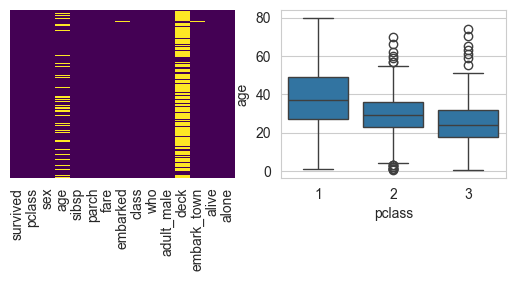

In [35]:
plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.subplot(2, 2, 2)
sns.boxplot(x='pclass', y='age', data=df)

In [33]:
#dealing with missing data
#we are just returning the average age for each class
def impute_age(cols):
		age = cols[0]
		pclass = cols[1]
		
		if pd.isnull(age):
				if pclass == 1:
						return 37
				elif pclass == 2:
						return 29
				else:
						return 24
		else:
				return age

In [34]:
df['age'] = df[['age', 'pclass']].apply(impute_age, axis=1)

KeyError: 0

# people who survived on titanic

<Axes: xlabel='survived', ylabel='count'>

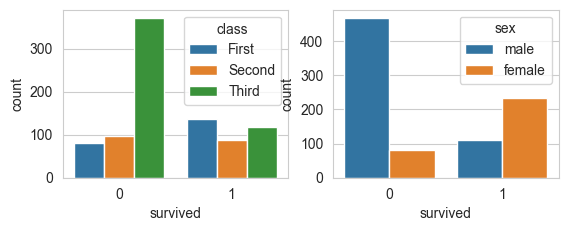

In [16]:
sns.set_style('whitegrid')
plt.subplot(2, 2, 1)
sns.countplot(x='survived',hue='class', data=df)
plt.subplot(2, 2, 2)
sns.countplot(x='survived',hue='sex', data=df)


C:\Users\Akmal Khan\AppData\Local\Temp\ipykernel_10188\2091281627.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'].dropna(), kde=False, bins=60)


<Axes: xlabel='age'>

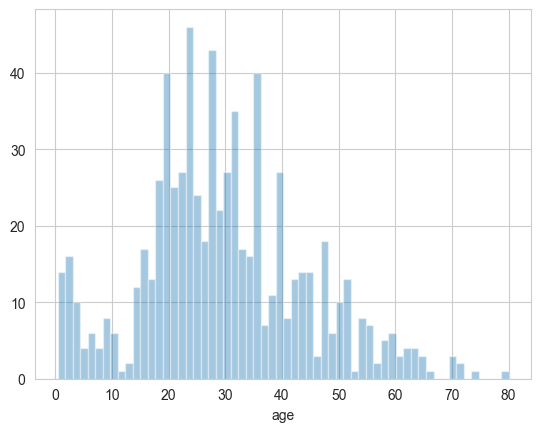

In [24]:
# plt.subplot(2, 2, 1)
sns.distplot(df['age'].dropna(), kde=False, bins=60)